In [1]:
from pathlib import Path
from textalloc import allocate
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from country_config import *
from run_config import *
from utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))

population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")

# 1) Use the original dict
country_dict = {
    "population_scale": population_scale_from_input_yml,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))

data_path = Path("data")
exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print("\ndata_path:", data_path)
print("output_path:", output_path)
print("analysis_path:", analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Birth rate: 0.0362
Public percentage: 0.445
Private percentage: 0.555

data_path: data
output_path: validation_1_copy_new_treatment_seeking_zero_beta/output
analysis_path: validation_1_copy_new_treatment_seeking_zero_beta/analysis


## PfPR

In [3]:
output_path_obj = Path(output_path)
if not output_path_obj.exists() or not output_path_obj.is_dir():
    raise NotADirectoryError(f"Path {output_path} is not a valid directory.")
db_files = list(output_path_obj.glob("*.db"))
if len(db_files) == 0:
    raise FileNotFoundError(f"No .db files found in directory {output_path}.")

agg_population = pd.DataFrame(columns=["monthly_data_id", "unit_id", "population"])
agg_treatment = pd.DataFrame(columns=["monthly_data_id", "unit_id", "treatments"])
agg_clinical_episodes = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes"])
agg_prevalence_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_2to10"])
agg_clinical_episodes_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"])
agg_prevalence_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_under5"])
agg_clinical_episodes_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_under5"])

rep = 0
for file in output_path_obj.glob("*.db"):
    data = get_table(file, "monthly_site_data_district")
    clinical_episodes_2_to_10 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].copy()
    clinical_episodes_2_to_10["clinical_episodes_2_to_10"] = clinical_episodes_2_to_10[
        [
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].sum(axis=1)
    clinical_episodes_under_5 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].copy()
    clinical_episodes_under_5["clinical_episodes_under5"] = clinical_episodes_under_5[
        [
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].sum(axis=1)
    
    # Add a column to the agg_* data frames from data
    try:
        agg_population = agg_population.merge(
            data[["monthly_data_id", "unit_id", "population"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_treatment = agg_treatment.merge(
            data[["monthly_data_id", "unit_id", "treatments"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes = agg_clinical_episodes.merge(
            data[["monthly_data_id", "unit_id", "clinical_episodes"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_2_to_10 = agg_prevalence_2_to_10.merge(
            data[["monthly_data_id", "unit_id", "pfpr_2to10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        
        agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.merge(
            clinical_episodes_2_to_10[["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_under_5 = agg_prevalence_under_5.merge(
            data[["monthly_data_id", "unit_id", "pfpr_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.merge(
            clinical_episodes_under_5[["monthly_data_id", "unit_id", "clinical_episodes_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
    except Exception as e:
        error(f"Error processing replicate {rep}: {e}")
    rep += 1
    
agg_population = agg_population.drop(columns=["population"])
agg_treatment = agg_treatment.drop(columns=["treatments"])
agg_clinical_episodes = agg_clinical_episodes.drop(columns=["clinical_episodes"])
agg_prevalence_2_to_10 = agg_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.drop(columns=["clinical_episodes_2_to_10"])
agg_prevalence_under_5 = agg_prevalence_under_5.drop(columns=["pfpr_under5"])
agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.drop(columns=["clinical_episodes_under5"])

agg_prevalence_2_to_10.to_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv", index=False)
agg_clinical_episodes_2_to_10.to_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv", index=False)
agg_prevalence_under_5.to_csv(f"{analysis_path}/agg_prevalence_under_5.csv", index=False)
agg_clinical_episodes_under_5.to_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv", index=False)
agg_population.to_csv(f"{analysis_path}/agg_population.csv", index=False)
agg_treatment.to_csv(f"{analysis_path}/agg_treatment.csv", index=False)
agg_clinical_episodes.to_csv(f"{analysis_path}/agg_clinical_episodes.csv", index=False)

In [4]:
agg_clinical_episodes.tail(24)
agg_clinical_episodes = agg_clinical_episodes.sort_values("unit_id", ascending=False).reset_index(drop=True)
unit_id_to_inspect = 6
agg_clinical_episodes.loc[
    agg_clinical_episodes["unit_id"] == unit_id_to_inspect
].sort_values("monthly_data_id")
agg_clinical_episodes.tail(24)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2
144,7,1,187.0,191.0,188
145,6,1,707.0,614.0,694
146,5,1,2269.0,2220.0,2203
147,8,1,72.0,57.0,58
148,10,1,7.0,4.0,6
149,9,1,20.0,28.0,22
150,11,1,0.0,5.0,4
151,12,1,0.0,2.0,1
152,18,1,0.0,0.0,0
153,17,1,0.0,0.0,0


In [5]:
months = np.sort(agg_clinical_episodes["monthly_data_id"].unique())
end_month = int(months[-1]) + 1
start_month = end_month - 12

In [6]:
agg_test = pd.DataFrame(columns=["monthly_data_id", "unit_id"])

In [7]:
data_test = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes",
            "population",
            "treatments"
        ]    
    ].copy()

In [8]:
agg_test

,monthly_data_id,unit_id


In [9]:
data_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1339989,0
1,1,2,0,830894,0
2,1,3,0,680885,0
3,1,4,0,576519,0
4,1,5,0,986423,0
...,...,...,...,...,...
163,28,2,0,866453,0
164,28,3,0,708130,0
165,28,4,0,607306,0
166,28,5,0,1029972,0


In [10]:
agg_test = agg_test.merge(
    data[["monthly_data_id", "unit_id", "clinical_episodes","population","treatments"]].copy(),
    how="outer",
    on=["monthly_data_id", "unit_id"],
    suffixes=("", f"_{validation_replicates}"),
)

In [11]:
agg_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1339989,0
1,1,2,0,830894,0
2,1,3,0,680885,0
3,1,4,0,576519,0
4,1,5,0,986423,0
...,...,...,...,...,...
163,28,2,0,866453,0
164,28,3,0,708130,0
165,28,4,0,607306,0
166,28,5,0,1029972,0


In [12]:
agg_test_at_calib = agg_test.loc[agg_test["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()

In [13]:
g = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"]

In [14]:
for unit_id, vals in g:
    print("unit_id:", unit_id)
    print(vals)
    print()

unit_id: 1
96     0
102    0
108    0
114    0
120    0
126    0
132    0
138    0
144    0
150    0
156    0
162    0
Name: clinical_episodes, dtype: int64

unit_id: 2
97     0
103    0
109    0
115    0
121    0
127    0
133    0
139    0
145    0
151    0
157    0
163    0
Name: clinical_episodes, dtype: int64

unit_id: 3
98     0
104    0
110    0
116    0
122    0
128    0
134    0
140    0
146    0
152    0
158    0
164    0
Name: clinical_episodes, dtype: int64

unit_id: 4
99     0
105    0
111    0
117    0
123    0
129    0
135    0
141    0
147    0
153    0
159    0
165    0
Name: clinical_episodes, dtype: int64

unit_id: 5
100    0
106    0
112    0
118    0
124    0
130    0
136    0
142    0
148    0
154    0
160    0
166    0
Name: clinical_episodes, dtype: int64

unit_id: 6
101    0
107    0
113    0
119    0
125    0
131    0
137    0
143    0
149    0
155    0
161    0
167    0
Name: clinical_episodes, dtype: int64



In [15]:
agg_test_at_calib_mean_by_location = pd.DataFrame()
agg_test_at_calib_mean_by_location["clinical_episodes_mean"] = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"].sum()
agg_test_at_calib_mean_by_location["population_mean"] = agg_test_at_calib.copy().groupby("unit_id")["population"].mean()
agg_test_at_calib_mean_by_location["treatments_mean"] = agg_test_at_calib.copy().groupby("unit_id")["treatments"].sum()

In [16]:
agg_test_at_calib_mean_by_location

,clinical_episodes_mean,population_mean,treatments_mean
unit_id,,,
1,0,1.391214e+06,0
2,0,8.582539e+05,0
3,0,7.014532e+05,0
4,0,6.013689e+05,0
5,0,1.019812e+06,0
6,0,7.091814e+05,0


In [17]:
agg_test_at_calib_mean_by_location.sum(axis=0)

clinical_episodes_mean    0.000000e+00
population_mean           5.281283e+06
treatments_mean           0.000000e+00
dtype: float64

In [18]:
agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [19]:
agg_clinical_episodes.tail(6)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2
162,28,1,NaN,NaN,0
163,28,2,NaN,NaN,0
164,28,3,NaN,NaN,0
165,28,4,NaN,NaN,0
166,28,5,NaN,NaN,0
167,28,6,NaN,NaN,0


In [20]:
data_at_calib = agg_clinical_episodes.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()
data_at_calib

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2
96,17,1,0.0,0.0,0
97,17,2,0.0,0.0,0
98,17,3,0.0,0.0,0
99,17,4,0.0,0.0,0
100,17,5,0.0,0.0,0
...,...,...,...,...,...
163,28,2,NaN,NaN,0
164,28,3,NaN,NaN,0
165,28,4,NaN,NaN,0
166,28,5,NaN,NaN,0


In [21]:
data_at_calib_sum_1_year = data_at_calib.groupby("unit_id").sum().reset_index()
data_at_calib_sum_1_year

,unit_id,monthly_data_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2
0,1,270,0.0,0.0,0
1,2,270,0.0,0.0,0
2,3,270,0.0,0.0,0
3,4,270,0.0,0.0,0
4,5,270,0.0,0.0,0
5,6,270,0.0,0.0,0


In [22]:
data_at_calib_mean_all_rep_1_year = data_at_calib_sum_1_year.copy().drop(columns=["monthly_data_id"]).mean(axis=1)
data_at_calib_mean_all_rep_1_year

0    0.25
1    0.50
2    0.75
3    1.00
4    1.25
5    1.50
dtype: float64

In [23]:
data_at_calib_mean_all_rep_1_year.sum()

np.float64(5.25)

In [24]:
mean_treatment = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_treatment = mean_treatment.drop(columns=["monthly_data_id"])
# mean_treatment = mean_treatment.drop(columns=["clinical_episodes"])
mean_treatment["mean"] = mean_treatment.mean(axis=1)
mean_treatment["std"] = mean_treatment.std(axis=1)

mean_clinical_episodes = (
    agg_clinical_episodes.loc[agg_clinical_episodes["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_clinical_episodes = mean_clinical_episodes.drop(columns=["monthly_data_id"])
# mean_clinical_episodes = mean_clinical_episodes.drop(columns=["clinical_episodes"])
mean_clinical_episodes["mean"] = mean_clinical_episodes.mean(axis=1)
mean_clinical_episodes["std"] = mean_clinical_episodes.std(axis=1)

mean_population = (
    agg_population.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_population = mean_population.drop(columns=["monthly_data_id"])
# mean_population = mean_population.drop(columns=["population"])
mean_population["mean"] = mean_population.mean(axis=1)
mean_population["std"] = mean_population.std(axis=1)

mean_prevalence_2_to_10 = (
    agg_prevalence_2_to_10.loc[
        agg_prevalence_2_to_10["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["monthly_data_id"])
# mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
mean_prevalence_2_to_10["mean"] = mean_prevalence_2_to_10.mean(axis=1)
mean_prevalence_2_to_10["std"] = mean_prevalence_2_to_10.std(axis=1)

mean_prevalence_under_5 = (
    agg_prevalence_under_5.loc[
        agg_prevalence_under_5["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["monthly_data_id"])
# mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["pfpr_under5"])
mean_prevalence_under_5["mean"] = mean_prevalence_under_5.mean(axis=1)
mean_prevalence_under_5["std"] = mean_prevalence_under_5.std(axis=1)

mean_clinical_episodes.to_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment.to_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10.to_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5.to_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population.to_csv(f"{analysis_path}/mean_population.csv")

In [25]:
mean_prevalence_2_to_10

,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,mean,std
unit_id,,,,,
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0


In [26]:
mean_population

,population_0,population_1,population_2,mean,std
unit_id,,,,,
1,1.388356e+06,1.390436e+06,1.391214e+06,1.390002e+06,1206.238769
2,8.562129e+05,8.578687e+05,8.582539e+05,8.574452e+05,885.435612
3,6.997690e+05,7.005000e+05,7.014532e+05,7.005741e+05,689.584789
4,6.001399e+05,6.012296e+05,6.013689e+05,6.009128e+05,549.490455
5,1.016878e+06,1.019029e+06,1.019812e+06,1.018573e+06,1240.178825
6,7.076111e+05,7.089613e+05,7.091814e+05,7.085846e+05,694.202923


In [27]:
mean_clinical_episodes

,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,mean,std
unit_id,,,,,
1,0.0,0.0,0,0.0,0.0
2,0.0,0.0,0,0.0,0.0
3,0.0,0.0,0,0.0,0.0
4,0.0,0.0,0,0.0,0.0
5,0.0,0.0,0,0.0,0.0
6,0.0,0.0,0,0.0,0.0


In [28]:
incidence_per_1000_sanity_check = mean_clinical_episodes["mean"] / mean_population["mean"] * 1000
incidence_per_1000_sanity_check

unit_id
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
Name: mean, dtype: float64

In [29]:
mean_treatment

,treatments_0,treatments_1,treatments_2,mean,std
unit_id,,,,,
1,0.0,0.0,0,0.0,0.0
2,0.0,0.0,0,0.0,0.0
3,0.0,0.0,0,0.0,0.0
4,0.0,0.0,0,0.0,0.0
5,0.0,0.0,0,0.0,0.0
6,0.0,0.0,0,0.0,0.0


In [30]:
total_mean_clinical_episodes = mean_clinical_episodes["mean"].sum()
total_mean_treatment = mean_treatment["mean"].sum()
total_mean_population = mean_population["mean"].sum()

print(f"Total mean clinical episodes (all districts): {total_mean_clinical_episodes:,.0f}")
print(f"Total mean treatments (all districts): {total_mean_treatment:,.0f}")
print(f"Total mean population (all districts): {total_mean_population:,.0f}")

Total mean clinical episodes (all districts): 0
Total mean treatments (all districts): 0
Total mean population (all districts): 5,276,092


In [31]:
mean_clinical_episodes = pd.read_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment = pd.read_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5 = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population = pd.read_csv(f"{analysis_path}/mean_population.csv")

In [32]:
mean_prevalence_2_to_10

,unit_id,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,mean,std
0,1,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0
5,6,0.0,0.0,0.0,0.0,0.0


In [33]:
district_mapping = pd.read_csv(data_path / f"{country_code}_mapping.csv")
district_mapping.columns = ["district_name", "unit_id"]
district_mapping

,district_name,unit_id
0,Benue,7
1,Cross River,9
2,Ebonyi,11
3,Nassarawa,26
4,Plateau,32
5,Taraba,35


In [34]:
district_raster, district_metadata = read_raster(f"{data_path}/{country_code}_district.asc")
prevalence_obs, prevalence_metadata = read_raster(f"{data_path}/{country_code}_pfpr_2024.asc")
observed_incidence_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
old_to_new_district_id_mapping = pd.read_csv(f"{data_path}/{country_code}_district_seq1_mapping.csv")

prevalence_nodata = prevalence_metadata["NODATA_value"]
district_nodata = district_metadata["NODATA_value"]

valid_districts = district_raster[district_raster != district_nodata]
valid_prevalence = prevalence_obs[prevalence_obs != prevalence_nodata]

data_sim = pd.DataFrame({"unit_id": mean_prevalence_2_to_10.unit_id, 
                                "mean_2_to_10_sim": mean_prevalence_2_to_10["mean"],
                                "mean_population_sim": mean_population["mean"],
                                "mean_clinical_episodes_sim": mean_clinical_episodes["mean"],
                                "mean_treatment_sim": mean_treatment["mean"],
                                })
data_sim["mean_2_to_10_sim"] = data_sim["mean_2_to_10_sim"].div(100)
data_sim["mean_population_sim"] = data_sim["mean_population_sim"] / country.population_scale
# Get total public and private from public cases and percentage private over public
data_sim["mean_clinical_episodes_sim"] = data_sim["mean_clinical_episodes_sim"] / country.population_scale
data_sim["mean_treatment_sim"] = (data_sim["mean_treatment_sim"] / country.population_scale) * public_pct

# Map to new unit id
data_sim["unit_id"] = data_sim["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])

In [35]:
data_sim

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim
0,7,0.0,5.560008e+06,0.0,0.0
1,9,0.0,3.429781e+06,0.0,0.0
2,11,0.0,2.802296e+06,0.0,0.0
3,26,0.0,2.403651e+06,0.0,0.0
4,32,0.0,4.074291e+06,0.0,0.0
5,35,0.0,2.834338e+06,0.0,0.0


In [36]:
prevalence_district_obs = pd.DataFrame({"unit_id": valid_districts.flatten(), "mean_2_to_10_obs": valid_prevalence.flatten()})
prevalence_district_mean_obs = prevalence_district_obs.groupby("unit_id")["mean_2_to_10_obs"].mean().to_frame()
pop_clinical_episodes_obs = pd.read_csv(f"{data_path}/population_incidence_per_district.csv")

observed_incidence_per_district = observed_incidence_per_district.iloc[:-1]

compare_data = data_sim.merge(observed_incidence_per_district, left_on="unit_id", right_on="Region ID", how="outer")
compare_data = compare_data.merge(prevalence_district_mean_obs, left_on="unit_id", right_on="unit_id", how="outer")
compare_data.rename(columns={"Population (2021 target based on worldometers birth rate and wordpop raster counts)": "population_obs"}, inplace=True)
compare_data.rename(columns={"Total Cases 2021 from projected population and observed incidence": "annual_clinical_episodes_obs"}, inplace=True)
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from rasters),Growth Rate (2019-2020),population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs
0,7,0.0,5.560008e+06,0.0,0.0,Benue,7.0,257.2,5787706,6464378,1.116915,6601202,1697829,0.296162
1,9,0.0,3.429781e+06,0.0,0.0,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327,1182153,0.333528
2,11,0.0,2.802296e+06,0.0,0.0,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353832,1245948,0.266297
3,26,0.0,2.403651e+06,0.0,0.0,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686,778632,0.289176
4,32,0.0,4.074291e+06,0.0,0.0,Plateau,32.0,286.5,4400974,4758921,1.081334,4859648,1392289,0.218215
5,35,0.0,2.834338e+06,0.0,0.0,Taraba,35.0,299.9,3331885,3274257,0.982704,3343560,1002734,0.290542


In [37]:
print(f"Total observed clinical episodes (all districts): {compare_data['annual_clinical_episodes_obs'].sum():.0f}")
print(f"Total observed population (all districts): {compare_data['population_obs'].sum():.0f}")

Total observed clinical episodes (all districts): 7299585
Total observed population (all districts): 25092255


### Multiply Sim Clinical Episodes by Treatment Access Rate and Public Sector for Comparision to Observed Data

In [38]:
print(f"Public treatment percentage: {public_pct * 100}%")

Public treatment percentage: 44.5%


In [39]:
compare_data["adjusted_mean_clinical_episodes_sim"] = compare_data["mean_clinical_episodes_sim"] * public_pct
compare_data[["adjusted_mean_clinical_episodes_sim", "mean_clinical_episodes_sim"]] 

,adjusted_mean_clinical_episodes_sim,mean_clinical_episodes_sim
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0


In [40]:
compare_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [41]:
compare_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [42]:
# ======================================================
# Load data
# ======================================================
csv_path = f"{analysis_path}/compare_data_pfpr_pop_incidence.csv"
compare_data = pd.read_csv(csv_path)

# Optional style
# sns.set_style("whitegrid")

<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_978633/1739925926.py:68: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",


No non overlapping boxes found


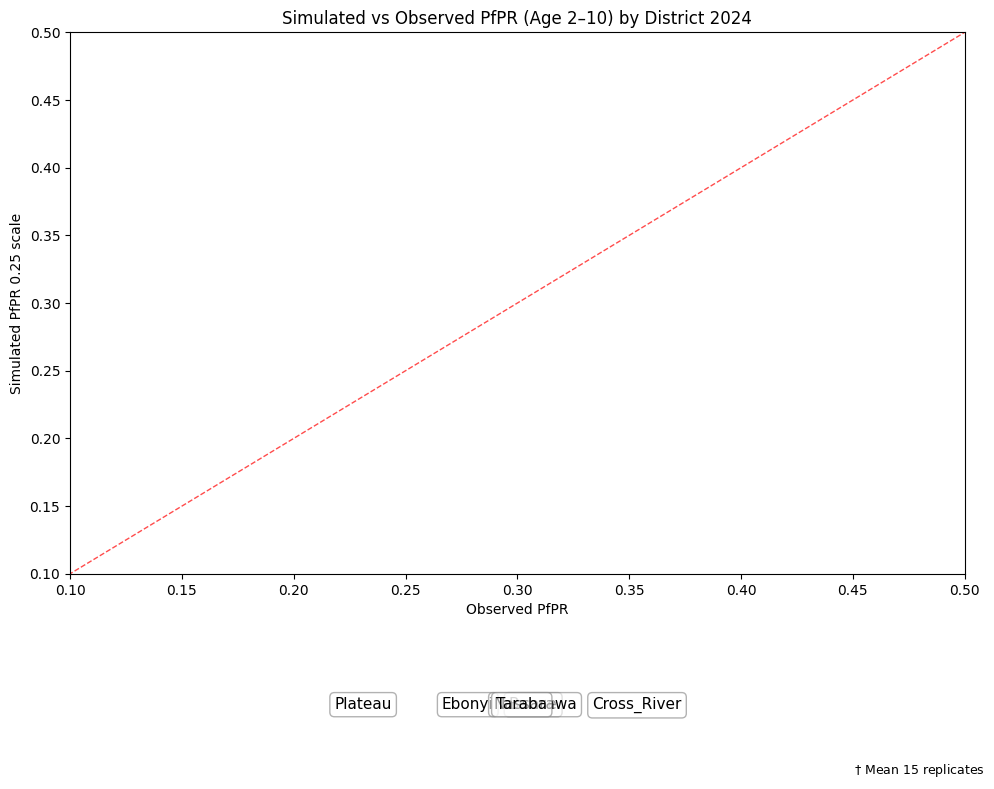

In [43]:
# ======================================================
# Figure 1: Simulated vs Observed PfPR by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d1 = compare_data[["mean_2_to_10_obs", "mean_2_to_10_sim", "State", "mean_population_sim"]].dropna(
    subset=["mean_2_to_10_obs", "mean_2_to_10_sim"]
)

sns.scatterplot(
    data=d1,
    x="mean_2_to_10_obs",
    y="mean_2_to_10_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

''' Use full range when trying to calibrate pipeline, narrow range yields better looking plots when finalized'''

# ax.set_xlim(0.0, 1.0)
# ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.1, 0.5)

span = min(ax.get_xlim()[1] - ax.get_xlim()[0], ax.get_ylim()[1] - ax.get_ylim()[0])

texts = d1["State"].astype(str).fillna("").tolist()
x = d1["mean_2_to_10_obs"].to_numpy(dtype=float)
y = d1["mean_2_to_10_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=11,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.02,
    min_distance=0.10 * span,
    max_distance=0.35 * span,
    nbr_candidates=3000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1, color="red", alpha=0.7)
ax.set_title(f"Simulated vs Observed PfPR (Age 2–10) by District {calibration_year}")
ax.set_xlabel("Observed PfPR")
ax.set_ylabel(f"Simulated PfPR {population_scale_from_input_yml} scale")

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='right', va='bottom', fontsize=9)
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

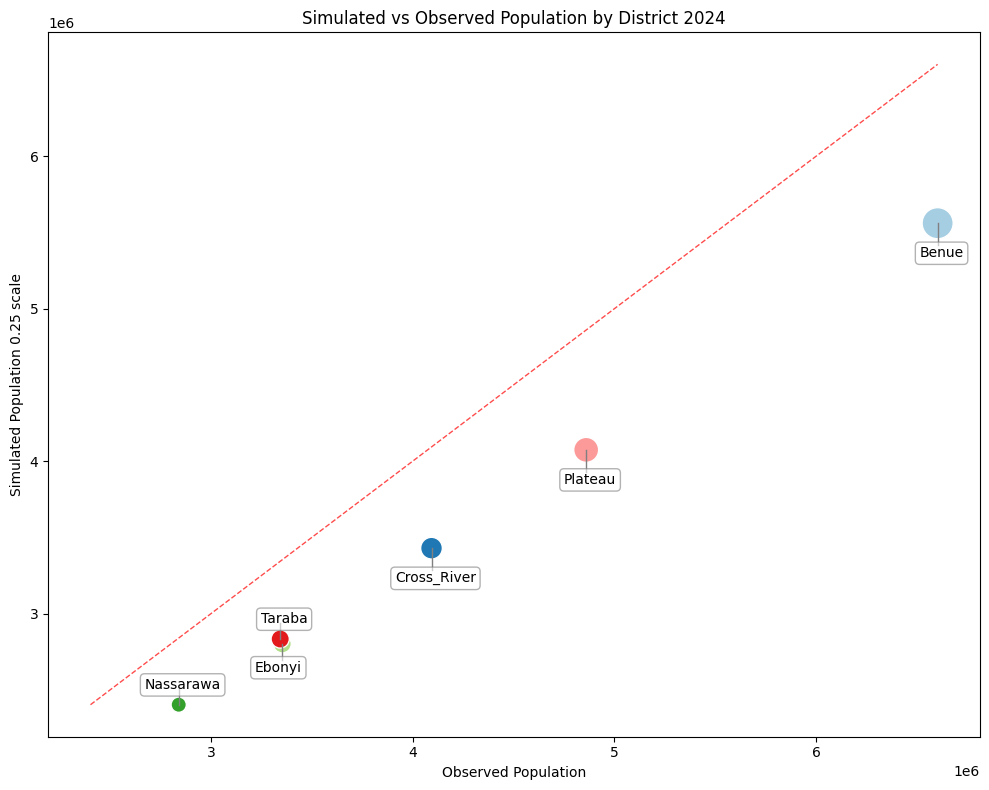

In [44]:
# ======================================================
# Figure 2: Simulated vs Observed Population by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d2 = compare_data[["population_obs", "mean_population_sim", "State"]].dropna(
    subset=["population_obs", "mean_population_sim"]
)

sns.scatterplot(
    data=d2,
    x="population_obs",
    y="mean_population_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

texts = d2["State"].astype(str).fillna("").tolist()
x = d2["population_obs"].to_numpy(dtype=float)
y = d2["mean_population_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=10,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.01,
    min_distance=0.01,
    max_distance=0.08,
    nbr_candidates=300,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

min_val = min(d2["population_obs"].min(), d2["mean_population_sim"].min())
max_val = max(d2["population_obs"].max(), d2["mean_population_sim"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="red", alpha=0.7)

ax.set_title(f"Simulated vs Observed Population by District {calibration_year}")
ax.set_xlabel("Observed Population")
ax.set_ylabel(f"Simulated Population {population_scale_from_input_yml} scale")

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Population_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

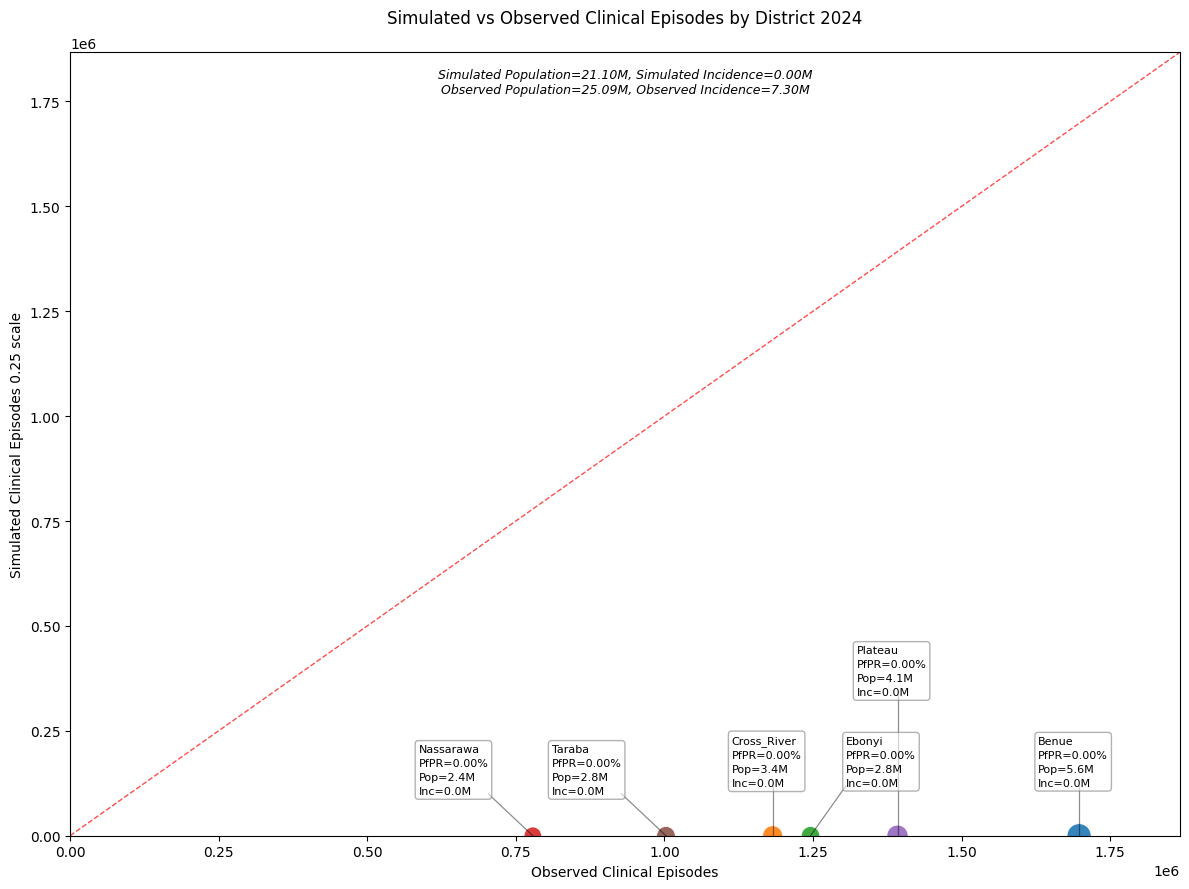

In [45]:
# ======================================================
# Figure 3: Simulated vs Observed Clinical Episodes by District
# ======================================================
fig, ax = plt.subplots(figsize=(12, 9))

d4 = compare_data[
    [
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "State",
        "mean_2_to_10_sim",
        "population_obs"
    ]
].dropna(
    subset=[
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "mean_2_to_10_sim",
        "population_obs"
    ]
).copy()

x = d4["annual_clinical_episodes_obs"].to_numpy(float)
# y = d4["mean_clinical_episodes_sim"].to_numpy(float)
y = d4["adjusted_mean_clinical_episodes_sim"].to_numpy(float)

pop = d4["mean_population_sim"].to_numpy(float)
sizes = (pop / pop.max()) * 250.0 + 50.0

total_pop_sim = d4["mean_population_sim"].sum()
# total_clinical_episodes_sim = d4["mean_clinical_episodes_sim"].sum()
total_clinical_episodes_sim = d4["adjusted_mean_clinical_episodes_sim"].sum()
total_pop_obs = d4["population_obs"].sum()
total_clinical_episodes_obs = d4["annual_clinical_episodes_obs"].sum()

texts = []
for _, row in d4.iterrows():
    name = str(row["State"])
    pfpr = row["mean_2_to_10_sim"]
    population = row["mean_population_sim"]
    # cases = row["mean_clinical_episodes_sim"]
    cases = row["adjusted_mean_clinical_episodes_sim"]
    label = f"{name}\nPfPR={pfpr*100:.2f}%\nPop={population/1e6:.1f}M\nInc={cases/1e6:.1f}M"
    texts.append(label)

districts = d4["State"].astype(str).tolist()
palette = sns.color_palette("tab10", n_colors=len(districts))
color_map = {name: palette[i] for i, name in enumerate(districts)}
colors = [color_map[name] for name in districts]

sc = ax.scatter(
    x, y,
    s=sizes,
    c=colors,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=2,
)

maxv = max(np.nanmax(x), np.nanmax(y)) * 1.10
ax.set_xlim(0, maxv)
ax.set_ylim(0, maxv)

linecolor = [(0, 0, 0, 0.45)] * len(x)

allocate(
    ax, x, y, texts,
    scatter_plot=sc,
    textsize=8,
    draw_lines=True,
    draw_all=True,
    linecolor=linecolor,
    linewidth=0.9,
    margin=0.03,
    min_distance=0.04,
    max_distance=0.38,
    nbr_candidates=5000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot(ax.get_xlim(), ax.get_ylim(), color="red", linestyle="--", linewidth=1, zorder=1, alpha=0.7)
ax.set_xlabel("Observed Clinical Episodes")
ax.set_ylabel(f"Simulated Clinical Episodes {population_scale_from_input_yml} scale")
ax.set_title(
    f"Simulated vs Observed Clinical Episodes by District {calibration_year}\n"
)

ax.text(
    0.5, 0.98,
    f"Simulated Population={total_pop_sim/1e6:.2f}M, Simulated Incidence={total_clinical_episodes_sim/1e6:.2f}M\n"
    f"Observed Population={total_pop_obs/1e6:.2f}M, Observed Incidence={total_clinical_episodes_obs/1e6:.2f}M",
    transform=ax.transAxes,
    fontsize=9, color="black", style="italic",
    ha="center", va="top"
)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Clinical_Episodes_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

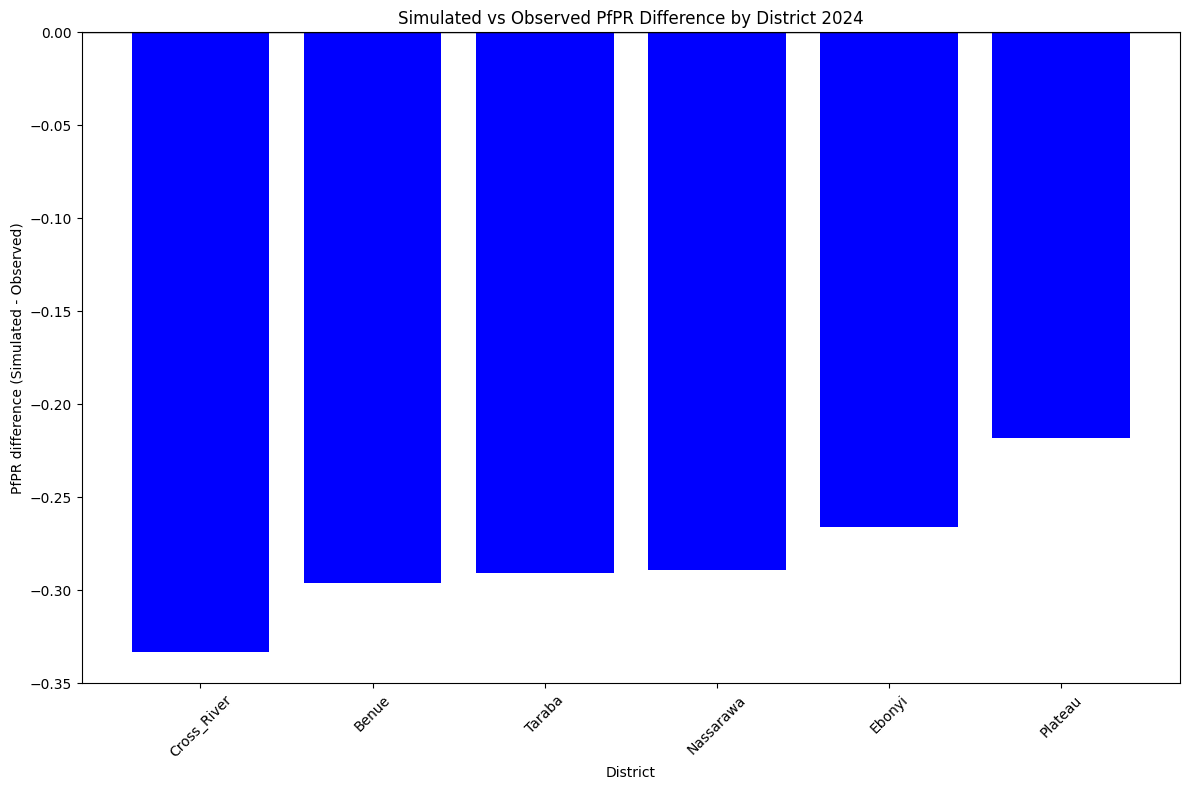

In [46]:
# ======================================================
# Figure 4: Simulated vs Observed PfPR difference by district
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8))

d3 = compare_data.copy()
d3["diff"] = d3["mean_2_to_10_sim"] - d3["mean_2_to_10_obs"]
d3 = d3.sort_values("diff")

colors = ["red" if d > 0 else "blue" for d in d3["diff"]]

ax.bar(d3["State"].astype(str), d3["diff"], color=colors)
ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("District")
ax.set_ylabel("PfPR difference (Simulated - Observed)")
ax.set_title(f"Simulated vs Observed PfPR Difference by District {calibration_year}")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_Difference_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()